In [18]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from pathlib import Path

In [19]:
# gradient descent minimises convex loss func
# loss = 1/n(y-y_hat)^2
# convergence tol : gradient norm, change in loss, change in coeffs

class OLS_GradientDescent:
    def __init__(self):
        self.coef_ = None
        self.loss_history_ = None
        self.gradient_ = None

    def fit(self, X, y, learning_rate=0.01, n_iterations=100_000,verbose = True, tol = 1e-6):

        self.loss_history_ = []
        
        n_samples, n_features = X.shape
        self.coef_ = np.zeros(n_features) # initisation b vector = 0

        for _ in range(n_iterations):

            y_pred = X @ self.coef_
            residuals = (y_pred-y)
            loss = np.mean(residuals ** 2)

            self.loss_history_.append(loss)

            gradient = (2/n_samples) * X.T @ residuals
            self.gradient_ = gradient

            if not np.all(np.isfinite(gradient)):
                print(f"Iteration {_}: non-finite gradient")
                print("coef:", self.coef_)
                print("y_pred:", y_pred)
                print("residuals:", residuals)
                print("gradient:", gradient)
                break

            if verbose and _ % 1000 == 0:
                print(
                    f"Iteration: {_}, "
                    f"max coef: {np.max(np.abs(self.coef_))}, "
                    f"max y_pred: {np.max(np.abs(y_pred))}, "
                    f"max residual: {np.max(np.abs(residuals))}, "
                    f"max gradient: {np.max(np.abs(gradient))}"
                )


            if np.linalg.norm(gradient) < tol:
                if verbose:
                    print(f"Converged at iteration {_}")

            self.coef_ -= learning_rate * gradient
            


        return self

    def predict(self,X):
        if self.coef_ is None:
           raise ValueError("Model has not been fitted.")
        return X @ self.coef_

   


In [20]:
df = sm.datasets.longley.load_pandas().data


y = df["TOTEMP"].to_numpy()
X = df.drop(columns="TOTEMP").to_numpy()
X = np.column_stack((
    np.ones(len(X)),
    X
))
print(X.shape)
print(y.shape)

(16, 7)
(16,)


In [21]:
print(X)
print(y)

[[1.00000e+00 8.30000e+01 2.34289e+05 2.35600e+03 1.59000e+03 1.07608e+05
  1.94700e+03]
 [1.00000e+00 8.85000e+01 2.59426e+05 2.32500e+03 1.45600e+03 1.08632e+05
  1.94800e+03]
 [1.00000e+00 8.82000e+01 2.58054e+05 3.68200e+03 1.61600e+03 1.09773e+05
  1.94900e+03]
 [1.00000e+00 8.95000e+01 2.84599e+05 3.35100e+03 1.65000e+03 1.10929e+05
  1.95000e+03]
 [1.00000e+00 9.62000e+01 3.28975e+05 2.09900e+03 3.09900e+03 1.12075e+05
  1.95100e+03]
 [1.00000e+00 9.81000e+01 3.46999e+05 1.93200e+03 3.59400e+03 1.13270e+05
  1.95200e+03]
 [1.00000e+00 9.90000e+01 3.65385e+05 1.87000e+03 3.54700e+03 1.15094e+05
  1.95300e+03]
 [1.00000e+00 1.00000e+02 3.63112e+05 3.57800e+03 3.35000e+03 1.16219e+05
  1.95400e+03]
 [1.00000e+00 1.01200e+02 3.97469e+05 2.90400e+03 3.04800e+03 1.17388e+05
  1.95500e+03]
 [1.00000e+00 1.04600e+02 4.19180e+05 2.82200e+03 2.85700e+03 1.18734e+05
  1.95600e+03]
 [1.00000e+00 1.08400e+02 4.42769e+05 2.93600e+03 2.79800e+03 1.20445e+05
  1.95700e+03]
 [1.00000e+00 1.10800

In [22]:
model = OLS_GradientDescent()
model.fit(X,y)
print(model.coef_)
print(model.predict(X))

Iteration: 0, max coef: 0.0, max y_pred: 0.0, max residual: 70551.0, max gradient: 51290341821.25
Iteration 32: non-finite gradient
coef: [-6.43626340e+298 -6.69967995e+300 -2.63950416e+304 -2.13744567e+302
 -1.72264172e+302 -7.65775488e+303 -1.25865511e+302]
y_pred: [-inf -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf
 -inf -inf]
residuals: [-inf -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf
 -inf -inf]
gradient: [-inf -inf -inf -inf -inf -inf -inf]
[-6.43626340e+298 -6.69967995e+300 -2.63950416e+304 -2.13744567e+302
 -1.72264172e+302 -7.65775488e+303 -1.25865511e+302]
[-inf -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf
 -inf -inf]


/var/folders/1p/y7cndqs50bdgrly60h_677pw0000gn/T/ipykernel_84748/3134972916.py:22: RuntimeWarning: overflow encountered in square
  loss = np.mean(residuals ** 2)


gradient becomes extremely large, numbers too large to be handled

gradient descent algorithm overshoots the true optimum because the learning rate is too large relative to the scale/curvature of the unscaled problem

In [23]:
# gradient of loss = 2/n * X.T * (X.T * B - y)
# at initialisation B = 0, gradient = -2/n * X.T * y


# gradient at iteration 0
n = X.shape[0]
g = -2/n * X.T * y
g

array([[-7.54037500e+03, -7.64025000e+03, -7.52137500e+03,
        -7.64837500e+03, -7.90262500e+03, -7.95487500e+03,
        -8.12362500e+03, -7.97012500e+03, -8.25237500e+03,
        -8.48212500e+03, -8.52112500e+03, -8.31412500e+03,
        -8.58187500e+03, -8.69550000e+03, -8.66637500e+03,
        -8.81887500e+03],
       [-6.25851125e+05, -6.76162125e+05, -6.63385275e+05,
        -6.84529562e+05, -7.60232525e+05, -7.80373237e+05,
        -8.04238875e+05, -7.97012500e+05, -8.35140350e+05,
        -8.87230275e+05, -9.23689950e+05, -9.21205050e+05,
        -9.66319125e+05, -9.93026100e+05, -1.00269959e+06,
        -1.03092649e+06],
       [-1.76662692e+09, -1.98207950e+09, -1.94092090e+09,
        -2.17671988e+09, -2.59976606e+09, -2.76033367e+09,
        -2.96825072e+09, -2.89404803e+09, -3.28006324e+09,
        -3.55553716e+09, -3.77289000e+09, -3.69601101e+09,
        -4.14250539e+09, -4.37036700e+09, -4.49068153e+09,
        -4.89354082e+09],
       [-1.77651235e+07, -1.77635812e

In [24]:
print("X min/max:", np.nanmin(X), np.nanmax(X))
print("y min/max:", np.nanmin(y), np.nanmax(y))

print("NaN in X:", np.isnan(X).any())
print("NaN in y:", np.isnan(y).any())

print("Inf in X:", np.isinf(X).any())
print("Inf in y:", np.isinf(y).any())

X min/max: 1.0 554894.0
y min/max: 60171.0 70551.0
NaN in X: False
NaN in y: False
Inf in X: False
Inf in y: False


scaling -> standardizing the features

In [25]:
X_mean = X[:, 1:].mean(axis=0)
X_std = X[:, 1:].std(axis=0)

X_scaled = X.copy().astype(float)
X_scaled[:, 1:] = (X[:, 1:] - X_mean) / X_std


In [26]:
model2 = OLS_GradientDescent()
model2.fit(X_scaled,y,learning_rate=0.01)
print(model2.coef_)
print(model2.predict(X_scaled))

Iteration: 0, max coef: 0.0, max y_pred: 0.0, max residual: 70551.0, max gradient: 130634.0
Iteration: 1000, max coef: 65316.99989007362, max y_pred: 71215.61215616012, max residual: 1058.0997538463707, max gradient: 25.18016111640761
Iteration: 2000, max coef: 65316.999999999825, max y_pred: 71193.57972683645, max residual: 1022.6402173098322, max gradient: 22.620309249936323
Iteration: 3000, max coef: 65316.999999999825, max y_pred: 71164.05611864106, max residual: 997.6456123849202, max gradient: 21.626642814759244
Iteration: 4000, max coef: 65316.999999999825, max y_pred: 71138.52098156419, max residual: 974.1936438145203, max gradient: 20.690501101065756
Iteration: 5000, max coef: 65316.999999999825, max y_pred: 71116.27146841346, max residual: 952.0184115776792, max gradient: 19.788792809957922
Iteration: 6000, max coef: 65316.999999999825, max y_pred: 71096.62163715473, max residual: 931.0186362367676, max gradient: 18.9224586675178
Iteration: 7000, max coef: 65316.999999999825,

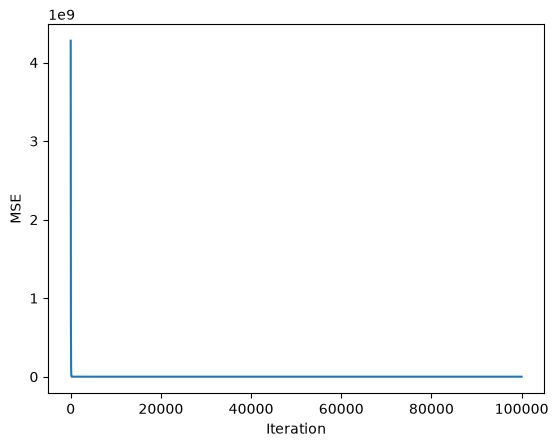

In [27]:
import matplotlib.pyplot as plt

plt.plot(model2.loss_history_)
plt.xlabel("Iteration")
plt.ylabel("MSE")
plt.show()

In [28]:
print("final loss:", model2.loss_history_[-1])

y_pred = X_scaled @ model2.coef_
residuals = y_pred - y

gradient = (2 / len(y)) * X_scaled.T @ residuals

print("gradient norm:", np.linalg.norm(gradient))


final loss: 56074.84536439917
gradient norm: 2.3984549101092614


In [29]:
model3 = OLS_GradientDescent()
model3.fit(X_scaled,y,learning_rate=0.01,n_iterations=1_000_000)
print(model3.coef_)
print(model3.predict(X_scaled))

Iteration: 0, max coef: 0.0, max y_pred: 0.0, max residual: 70551.0, max gradient: 130634.0
Iteration: 1000, max coef: 65316.99989007362, max y_pred: 71215.61215616012, max residual: 1058.0997538463707, max gradient: 25.18016111640761
Iteration: 2000, max coef: 65316.999999999825, max y_pred: 71193.57972683645, max residual: 1022.6402173098322, max gradient: 22.620309249936323
Iteration: 3000, max coef: 65316.999999999825, max y_pred: 71164.05611864106, max residual: 997.6456123849202, max gradient: 21.626642814759244
Iteration: 4000, max coef: 65316.999999999825, max y_pred: 71138.52098156419, max residual: 974.1936438145203, max gradient: 20.690501101065756
Iteration: 5000, max coef: 65316.999999999825, max y_pred: 71116.27146841346, max residual: 952.0184115776792, max gradient: 19.788792809957922
Iteration: 6000, max coef: 65316.999999999825, max y_pred: 71096.62163715473, max residual: 931.0186362367676, max gradient: 18.9224586675178
Iteration: 7000, max coef: 65316.999999999825,

In [30]:
print("final loss:", model3.loss_history_[-1])

y_pred = X_scaled @ model3.coef_
residuals = y_pred - y

gradient = (2 / len(y)) * X_scaled.T @ residuals

print("gradient norm:", np.linalg.norm(gradient))

final loss: 52276.50836134387
gradient norm: 0.0027150786571450464


high multicollinearity, loss func bowl looks like a long narrow valley, GD takes painfully long to converge to the exact min

need to inspect eigenvalues and condition number

In [31]:
eigvals = np.linalg.eigvalsh(X_scaled.T @ X_scaled)

print("eigenvalues:")
print(eigvals)
# 7 cols in X, 7 eigenvalues
condition_number = eigvals.max() / eigvals.min()

print("condition number:")
print(condition_number)

eigenvalues:
[6.02733012e-03 4.08330522e-02 2.38852139e-01 3.25480596e+00
 1.60000000e+01 1.88054480e+01 7.36540335e+01]
condition number:
12220.009860266153
